Elizabeth Meyer

COSC 6330

Healthcare Provider Fraud Prediction

In [1]:
# Imports needed libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

DATA EXPLORATION

In [2]:
# Imports train datasets
inpatient = pd.read_csv("InpatientTRAIN.csv")
outpatient = pd.read_csv("OutpatientTRAIN.csv")
beneficiary = pd.read_csv("BeneficiaryTRAIN.csv")

train = pd.read_csv("train.csv")

In [3]:
# Class imbalance in the provider fraud labels
class_counts = train["PotentialFraud"].value_counts()
class_pct = train["PotentialFraud"].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    "count": class_counts,
    "percent": class_pct.round(2)
})

print(imbalance_df)


                count  percent
PotentialFraud                
No               4904    90.65
Yes               506     9.35


In [4]:
# Number of missing values
missing = inpatient.isna().sum().sum()
print(f"Number of missing values: {missing}")

print("\nMissing values per column:")
print(inpatient.isna().sum())

Number of missing values: 344003

Missing values per column:
BeneID                        0
ClaimID                       0
ClaimStartDt                  0
ClaimEndDt                    0
Provider                      0
InscClaimAmtReimbursed        0
AttendingPhysician          112
OperatingPhysician        16644
OtherPhysician            35784
AdmissionDt                   0
ClmAdmitDiagnosisCode         0
DeductibleAmtPaid           899
DischargeDt                   0
DiagnosisGroupCode            0
ClmDiagnosisCode_1            0
ClmDiagnosisCode_2          226
ClmDiagnosisCode_3          676
ClmDiagnosisCode_4         1534
ClmDiagnosisCode_5         2894
ClmDiagnosisCode_6         4838
ClmDiagnosisCode_7         7258
ClmDiagnosisCode_8         9942
ClmDiagnosisCode_9        13497
ClmDiagnosisCode_10       36547
ClmProcedureCode_1        17326
ClmProcedureCode_2        35020
ClmProcedureCode_3        39509
ClmProcedureCode_4        40358
ClmProcedureCode_5        40465
ClmProcedur

DATA PREPROCESSING & FEATURE ENGINEERING

In [5]:
# Drops columns with 100% missingness
inpatient = inpatient.drop('ClmProcedureCode_6', axis=1)
outpatient = outpatient.drop('ClmProcedureCode_6', axis=1) 
outpatient = outpatient.drop('ClmProcedureCode_5', axis=1) 

In [6]:
# Inpatient Feature Engineering
inpatient["ClaimStartDt"] = pd.to_datetime(inpatient["ClaimStartDt"])
inpatient["ClaimEndDt"] = pd.to_datetime(inpatient["ClaimEndDt"])
inpatient["ClaimLength"] = (inpatient["ClaimEndDt"] - inpatient["ClaimStartDt"]).dt.days

inpatient["DeductibleAmtPaid"] = inpatient["DeductibleAmtPaid"].fillna(0)

inpatient["Has_Attending"] = inpatient["AttendingPhysician"].notna().astype(int)
inpatient["Has_Operating"] = inpatient["OperatingPhysician"].notna().astype(int)
inpatient["Has_Other"] = inpatient["OtherPhysician"].notna().astype(int)

diagnosis_cols_in = [f"ClmDiagnosisCode_{i}" for i in range(1, 11)]
inpatient["Num_Diagnoses"] = inpatient[diagnosis_cols_in].notna().sum(axis=1)
procedure_cols_in = [f"ClmProcedureCode_{i}" for i in range(1, 6)]
inpatient["Num_Procedures"] = inpatient[procedure_cols_in].notna().sum(axis=1)
inpatient["Has_Admit_Diagnosis"] = inpatient["ClmAdmitDiagnosisCode"].notna().astype(int)


In [7]:
# Outpatient Feature Engineering
outpatient["ClaimStartDt"] = pd.to_datetime(outpatient["ClaimStartDt"])
outpatient["ClaimEndDt"] = pd.to_datetime(outpatient["ClaimEndDt"])
outpatient["ClaimLength"] = (outpatient["ClaimEndDt"] - outpatient["ClaimStartDt"]).dt.days

outpatient["DeductibleAmtPaid"] = outpatient["DeductibleAmtPaid"].fillna(0)

outpatient["Has_Attending"] = outpatient["AttendingPhysician"].notna().astype(int)
outpatient["Has_Operating"] = outpatient["OperatingPhysician"].notna().astype(int)
outpatient["Has_Other"] = outpatient["OtherPhysician"].notna().astype(int)

diagnosis_cols_out = [f"ClmDiagnosisCode_{i}" for i in range(1, 11)]
outpatient["Num_Diagnoses"] = outpatient[diagnosis_cols_out].notna().sum(axis=1)
procedure_cols_out = [f"ClmProcedureCode_{i}" for i in range(1, 5)]
outpatient["Num_Procedures"] = outpatient[procedure_cols_out].notna().sum(axis=1)
outpatient["Has_Admit_Diagnosis"] = outpatient["ClmAdmitDiagnosisCode"].notna().astype(int)

In [8]:
# Beneficiary Feature Engineering
beneficiary["DOB"] = pd.to_datetime(beneficiary["DOB"])
# Will be assuming that 1/1/2010 is the current date, 2026 makes average age very old
beneficiary["Age"] = (pd.to_datetime("2010-01-01") - beneficiary["DOB"]).dt.days / 365

beneficiary["Is_Male"] = (beneficiary["Gender"] == 1).astype(int)

chronic_cols = [col for col in beneficiary.columns if "ChronicCond" in col]
beneficiary["Num_Chronic_Conditions"] = (beneficiary[chronic_cols] == 1).sum(axis=1)
beneficiary["RenalDisease"] = (beneficiary["RenalDiseaseIndicator"] == "Y").astype(int)

beneficiary["Is_Deceased"] = beneficiary["DOD"].notna().astype(int)

In [9]:
beneficiary["Age"].describe()

count    138556.000000
mean         73.721374
std          12.736338
min          26.104110
25%          68.131507
50%          74.386301
75%          82.057534
max         101.068493
Name: Age, dtype: float64

In [10]:
# Merges on Beneficiary ID
inpatient = inpatient.merge(beneficiary, on="BeneID", how="left")
outpatient = outpatient.merge(beneficiary, on="BeneID", how="left")

In [11]:
# Inpatient Provider Aggregation
inpatient_provider = inpatient.groupby("Provider").agg({
    #claims
    "ClaimID": "count",

    #money
    "InscClaimAmtReimbursed": ["mean", "std"],
    "DeductibleAmtPaid": ["mean"],

    #complexity
    "Num_Diagnoses": ["mean"],
    #"Num_Procedures": ["mean"],

    # admit
    "Has_Admit_Diagnosis": "mean",

    # patient mix
    "Age": "mean",
    "RenalDisease": "mean",
    "Num_Chronic_Conditions": "mean",

    # unique patients
    #"BeneID": pd.Series.nunique                
})

inpatient_provider.columns = ["_".join(col).strip() for col in inpatient_provider.columns.values]

inpatient_provider = inpatient_provider.reset_index()

In [12]:
# Outpatient Provider Aggregation
outpatient_provider = outpatient.groupby("Provider").agg({
    #claims
    "ClaimID": "count",

    #money
    "InscClaimAmtReimbursed": ["mean", "std"],
    "DeductibleAmtPaid": ["mean"],

    #complexity
    "Num_Diagnoses": ["mean"],
    #"Num_Procedures": ["mean"],

    # admit
    "Has_Admit_Diagnosis": "mean",

    # patient mix
    "Age": "mean",
    "RenalDisease": "mean",
    "Num_Chronic_Conditions": "mean",

    # unique patients
    #"BeneID": pd.Series.nunique                
})

outpatient_provider.columns = ["_".join(col).strip() for col in outpatient_provider.columns.values]

outpatient_provider = outpatient_provider.reset_index()

In [13]:
# Provider features used for model inputs
provider_features = inpatient_provider.merge(
    outpatient_provider,
    on="Provider",
    how="outer",
    suffixes=("_inpatient", "_outpatient")
)

provider_features = provider_features.fillna(0)

In [14]:
train_final = train.merge(provider_features, on="Provider", how="left")
train_final = train_final.fillna(0)

train_final.shape
train_final.head()

df = train_final.copy()

In [15]:
# Drops provider ID and label
X = train_final.drop(columns=["Provider", "PotentialFraud"])
y = (train_final["PotentialFraud"] == "Yes").astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2, # 80/20
    random_state=42,
    stratify=y # makes sure train and validation split keep same class proportions
)

In [16]:
# Standardizing the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

BASELINE LOGISTIC REGRESSION

In [17]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [18]:
train_pred = model.predict(X_train_scaled)
y_pred = model.predict(X_val_scaled)
y_prob = model.predict_proba(X_val_scaled)[:, 1]

# default threshold = 0.5
print("Logistic Regression - Training Set")
print(classification_report(y_train, train_pred))
print(confusion_matrix(y_train, train_pred))

print("\nLogistic Regression - Validation Set")
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print(f"Validation ROC AUC: {roc_auc_score(y_val, y_prob):.4f}")

# testing thresholds for LR function (VALIDATION ONLY)
for threshold in [0.3, 0.4, 0.6, 0.7]:
    y_pred_thresh = (y_prob >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print(classification_report(y_val, y_pred_thresh))
    print(confusion_matrix(y_val, y_pred_thresh))
    print("\n")


Logistic Regression - Training Set
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      3923
           1       0.39      0.85      0.53       405

    accuracy                           0.86      4328
   macro avg       0.68      0.86      0.72      4328
weighted avg       0.93      0.86      0.88      4328

[[3377  546]
 [  61  344]]

Logistic Regression - Validation Set
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       981
           1       0.38      0.87      0.53       101

    accuracy                           0.85      1082
   macro avg       0.68      0.86      0.72      1082
weighted avg       0.93      0.85      0.88      1082

[[837 144]
 [ 13  88]]
Validation ROC AUC: 0.9470
Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.73      0.84       981
           1       0.27      0.97      0.42       101

    accuracy     

Threshold 0.7 has superior performance.

In [19]:
# LR coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

coef_df.head(10)

,feature,coefficient
0,ClaimID_count_inpatient,1.552994
9,ClaimID_count_outpatient,1.181579
2,InscClaimAmtReimbursed_std_inpatient,0.429536
8,Num_Chronic_Conditions_mean_inpatient,0.366970
3,DeductibleAmtPaid_mean_inpatient,0.313338
15,Age_mean_outpatient,-0.258201
12,DeductibleAmtPaid_mean_outpatient,0.248311
10,InscClaimAmtReimbursed_mean_outpatient,-0.221505
1,InscClaimAmtReimbursed_mean_inpatient,0.217950
4,Num_Diagnoses_mean_inpatient,-0.180321


RANDOM FOREST

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced", # addresses class imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

print("Random Forest - Training Set")
print(classification_report(y_train, rf_train_pred))
print(confusion_matrix(y_train, rf_train_pred))

print("Random Forest - Validation Set")
print(classification_report(y_val, rf_pred))
print(confusion_matrix(y_val, rf_pred))
print(f"Validation ROC AUC: {roc_auc_score(y_val, rf_prob):.4f}")

rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(10)

Random Forest - Training Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3923
           1       0.97      1.00      0.98       405

    accuracy                           1.00      4328
   macro avg       0.98      1.00      0.99      4328
weighted avg       1.00      1.00      1.00      4328

[[3910   13]
 [   0  405]]
Random Forest - Validation Set
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       981
           1       0.71      0.60      0.65       101

    accuracy                           0.94      1082
   macro avg       0.83      0.79      0.81      1082
weighted avg       0.94      0.94      0.94      1082

[[956  25]
 [ 40  61]]
Validation ROC AUC: 0.9508


,feature,importance
0,ClaimID_count_inpatient,0.167634
2,InscClaimAmtReimbursed_std_inpatient,0.127195
9,ClaimID_count_outpatient,0.108718
1,InscClaimAmtReimbursed_mean_inpatient,0.088302
4,Num_Diagnoses_mean_inpatient,0.063098
8,Num_Chronic_Conditions_mean_inpatient,0.060707
6,Age_mean_inpatient,0.058132
7,RenalDisease_mean_inpatient,0.045031
12,DeductibleAmtPaid_mean_outpatient,0.034605
13,Num_Diagnoses_mean_outpatient,0.034603


In [24]:
train_pred = model.predict(X_train_scaled)
y_prob = model.predict_proba(X_val_scaled)[:, 1]
y_pred_07 = (y_prob >= 0.7).astype(int)

print("Logistic Regression - Training Set")
print(classification_report(y_train, train_pred))
print(confusion_matrix(y_train, train_pred))

print("\nLogistic Regression - Validation Set (Threshold = 0.7)")
print(classification_report(y_val, y_pred_07))
print(confusion_matrix(y_val, y_pred_07))
print(f"Validation ROC AUC: {roc_auc_score(y_val, y_prob):.4f}")


Logistic Regression - Training Set
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      3923
           1       0.39      0.85      0.53       405

    accuracy                           0.86      4328
   macro avg       0.68      0.86      0.72      4328
weighted avg       0.93      0.86      0.88      4328

[[3377  546]
 [  61  344]]

Logistic Regression - Validation Set (Threshold = 0.7)
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       981
           1       0.52      0.76      0.62       101

    accuracy                           0.91      1082
   macro avg       0.75      0.85      0.78      1082
weighted avg       0.93      0.91      0.92      1082

[[910  71]
 [ 24  77]]
Validation ROC AUC: 0.9470


XGBOOST

In [21]:
# handles class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_train_pred = xgb_model.predict(X_train)
xgb_pred = xgb_model.predict(X_val)
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]

print("XGBoost - Training Set")
print(classification_report(y_train, xgb_train_pred))
print(confusion_matrix(y_train, xgb_train_pred))

print("XGBoost - Validation Set")
print(classification_report(y_val, xgb_pred))
print(confusion_matrix(y_val, xgb_pred))
print(f"Validation ROC AUC: {roc_auc_score(y_val, xgb_prob):.4f}")

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importance.head(10)

XGBoost - Training Set
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      3923
           1       0.66      1.00      0.79       405

    accuracy                           0.95      4328
   macro avg       0.83      0.97      0.88      4328
weighted avg       0.97      0.95      0.96      4328

[[3711  212]
 [   1  404]]
XGBoost - Validation Set
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       981
           1       0.51      0.77      0.62       101

    accuracy                           0.91      1082
   macro avg       0.74      0.85      0.78      1082
weighted avg       0.93      0.91      0.92      1082

[[907  74]
 [ 23  78]]
Validation ROC AUC: 0.9498


,feature,importance
0,ClaimID_count_inpatient,0.272868
2,InscClaimAmtReimbursed_std_inpatient,0.114937
9,ClaimID_count_outpatient,0.109621
1,InscClaimAmtReimbursed_mean_inpatient,0.060760
14,Has_Admit_Diagnosis_mean_outpatient,0.040827
12,DeductibleAmtPaid_mean_outpatient,0.038711
10,InscClaimAmtReimbursed_mean_outpatient,0.038658
16,RenalDisease_mean_outpatient,0.035860
13,Num_Diagnoses_mean_outpatient,0.034432
15,Age_mean_outpatient,0.034191


ISOLATION FOREST

In [22]:
# Fit on non-fraud providers only so anomalies are defined relative to normal behavior
X_train_normal = X_train[y_train == 0]

iso_model = IsolationForest(
    n_estimators=300,
    # about 9%
    contamination=y_train.mean(),
    random_state=42
)

iso_model.fit(X_train_normal)

# IsolationForest returns -1 for anomaly and 1 for normal
iso_train_pred = (iso_model.predict(X_train) == -1).astype(int)
iso_pred = (iso_model.predict(X_val) == -1).astype(int)
iso_score = -iso_model.decision_function(X_val)

print("Isolation Forest - Training Set")
print(classification_report(y_train, iso_train_pred))
print(confusion_matrix(y_train, iso_train_pred))

print("Isolation Forest - Validation Set")
print(classification_report(y_val, iso_pred))
print(confusion_matrix(y_val, iso_pred))
print(f"Validation ROC AUC: {roc_auc_score(y_val, iso_score):.4f}")

iso_results = pd.DataFrame({
    "true_label": y_val.reset_index(drop=True),
    "predicted_fraud": iso_pred,
    "anomaly_score": iso_score
})

iso_results.head(10)

Isolation Forest - Training Set
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3923
           1       0.23      0.27      0.25       405

    accuracy                           0.85      4328
   macro avg       0.58      0.59      0.58      4328
weighted avg       0.86      0.85      0.85      4328

[[3555  368]
 [ 295  110]]
Isolation Forest - Validation Set
              precision    recall  f1-score   support

           0       0.92      0.89      0.91       981
           1       0.21      0.30      0.25       101

    accuracy                           0.83      1082
   macro avg       0.57      0.59      0.58      1082
weighted avg       0.86      0.83      0.84      1082

[[871 110]
 [ 71  30]]
Validation ROC AUC: 0.8026


,true_label,predicted_fraud,anomaly_score
0,0,0,-0.114994
1,0,0,-0.142662
2,0,0,-0.092835
3,0,0,-0.040739
4,0,0,-0.135899
5,0,0,-0.142371
6,0,0,-0.139053
7,0,0,-0.119990
8,0,1,0.073852
9,0,0,-0.138235


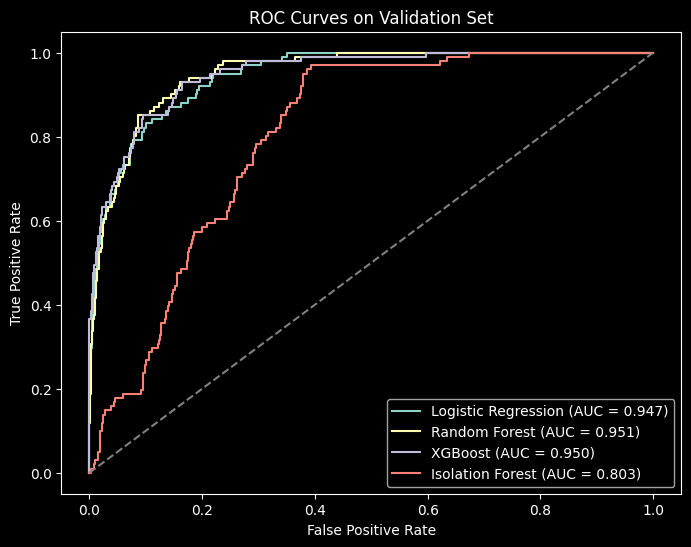

In [23]:
# ROC curves on the validation set
lr_fpr, lr_tpr, _ = roc_curve(y_val, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_prob)
iso_fpr, iso_tpr, _ = roc_curve(y_val, iso_score)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_val, y_prob):.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_val, rf_prob):.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {roc_auc_score(y_val, xgb_prob):.3f})")
plt.plot(iso_fpr, iso_tpr, label=f"Isolation Forest (AUC = {roc_auc_score(y_val, iso_score):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Validation Set")
plt.legend()
plt.show()